# Data Exploration of created books dataset 

In [1]:
import requests 
import pandas as pd 
import os 
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

In [3]:
#shape and columns of df 
print("shape: ", df.shape)
print("\ncolumns: ", df.columns.tolist())
print("\ndatatype: ", df.dtypes)

shape:  (810, 11)

columns:  ['title', 'authors', 'publisher', 'subject', 'categories', 'maturityRating', 'page_count', 'average_rating', 'ratings_count', 'published_date', 'description']

datatype:  title                        str
authors                      str
publisher                    str
subject                      str
categories                   str
maturityRating               str
page_count                 int64
average_rating           float64
ratings_count              int64
published_date    datetime64[us]
description                  str
dtype: object


In [4]:
#check for nulls 
print("missing values over columns: ")
print(df.isnull().sum())

#check for 0 values
print("\n0 values: ")
print((df[["page_count", "average_rating", "ratings_count"]] == 0).sum())

missing values over columns: 
title               0
authors             0
publisher           0
subject             0
categories          0
maturityRating      0
page_count          0
average_rating      0
ratings_count       0
published_date      0
description       111
dtype: int64

0 values: 
page_count          0
average_rating    697
ratings_count     697
dtype: int64


In [5]:
df[["page_count", "average_rating", "ratings_count"]].describe()


,page_count,average_rating,ratings_count
count,810.000000,810.000000,810.000000
mean,352.975309,0.564198,0.766667
std,187.723903,1.449676,6.388620
min,12.000000,0.000000,0.000000
25%,240.000000,0.000000,0.000000
50%,323.000000,0.000000,0.000000
75%,426.500000,0.000000,0.000000
max,2415.000000,5.000000,147.000000


page count distribution 

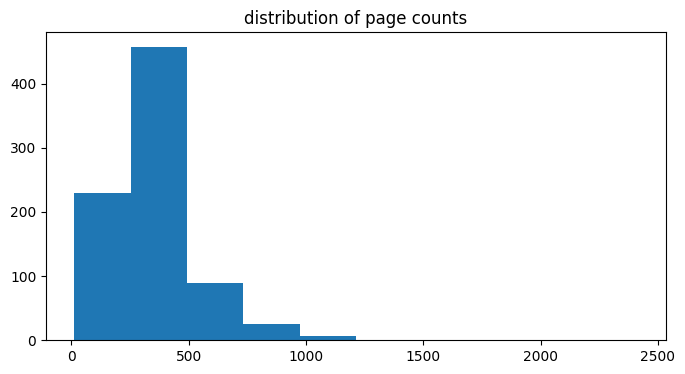

In [6]:
#remove 0 page counts
df_clean = df[df["page_count"] > 0]

plt.figure(figsize=(8, 4))
plt.hist(df_clean["page_count"], bins=10)
plt.title("distribution of page counts")
plt.show()

ratings

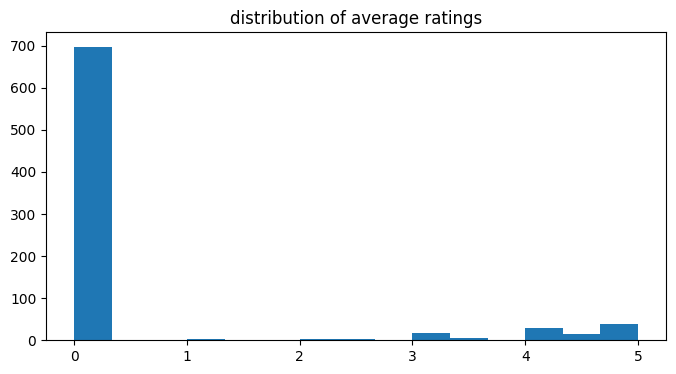

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean["average_rating"], bins=15)
plt.title("distribution of average ratings")
plt.show()

Genres

In [8]:
#determined by the genres given to API to pull 
genre_counts = df["subject"].value_counts()
genre_counts

subject
self help             100
fiction                89
science                88
mystery                87
science fiction        86
thriller               79
fantasy                76
nonfiction             76
romance                71
historical fiction     58
Name: count, dtype: int64

categories

In [9]:
#one layer down from genre 
category_counts = df["categories"].value_counts()
category_counts = category_counts[category_counts > 1]

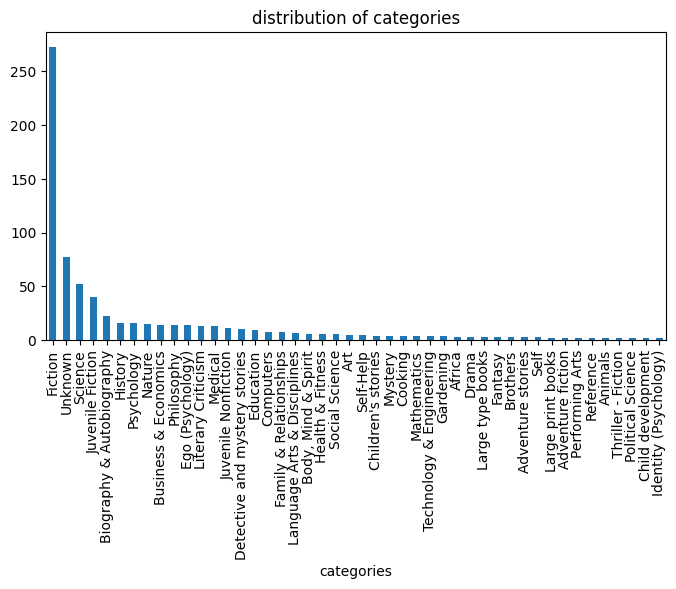

In [10]:
plt.figure(figsize=(8, 4))
category_counts.plot(kind="bar")
plt.title("distribution of categories")
plt.show()

Published Date 

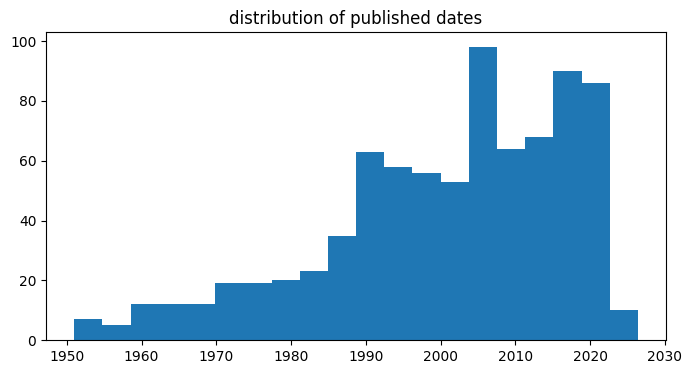

In [11]:
plt.figure(figsize = (8, 4))
plt.hist(df["published_date"], bins=20)
plt.title("distribution of published dates")
plt.show()

In [12]:
df["published_date"].describe()

count                           810
mean     2000-09-19 08:51:33.333333
min             1951-01-01 00:00:00
25%             1991-01-01 00:00:00
50%             2004-01-01 00:00:00
75%             2014-03-23 06:00:00
max             2026-05-28 00:00:00
Name: published_date, dtype: object